In [1]:
import pandas as pd 
import numpy as  np
import matplotlib.pyplot as plt 
from datetime import date 

In [5]:
df        = pd.read_csv("C:/Users/husai/OneDrive/Desktop/redrob_1/outputs/candidates_flat.csv")
df_skills = pd.read_csv("C:/Users/husai/OneDrive/Desktop/redrob_1/outputs/candidates_skills.csv")
df['last_active_date']=pd.to_datetime(df["last_active_date"])
df['days_since_active']=(pd.Timestamp(date.today())-df["last_active_date"]).dt.days

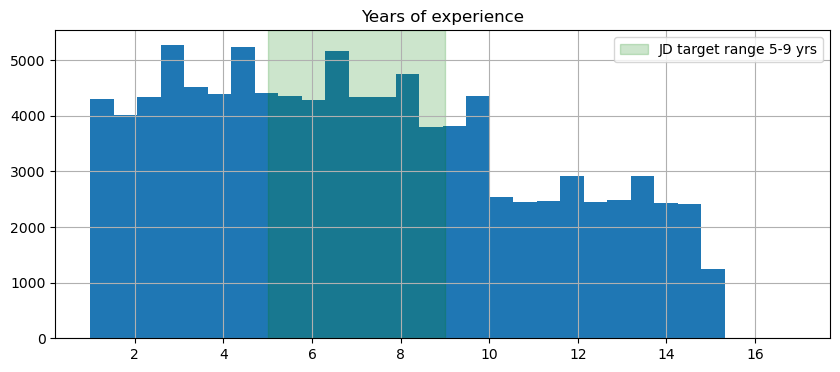

Candidates in 5-9yr band: 34,375 (34.4%)


In [6]:
df['years_of_experience'].hist(bins=30, figsize=(10,4))
plt.axvspan(5,9,alpha=0.2,color='green',label='JD target range 5-9 yrs')
plt.legend(); plt.title('Years of experience'); plt.show()
in_range = df[(df['years_of_experience']>=5)&(df['years_of_experience']<=9)]
print(f'Candidates in 5-9yr band: {len(in_range):,} ({100*len(in_range)/len(df):.1f}%)')

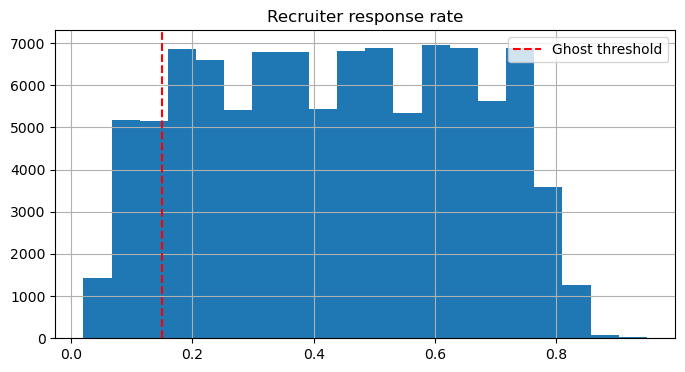

Ghost candidates (RRR<0.15): 10425
Active last 30d: 500


In [7]:
df['recruiter_response_rate'].hist(bins=20, figsize=(8,4))
plt.axvline(0.15,color='red',linestyle='--',label='Ghost threshold')
plt.legend(); plt.title('Recruiter response rate'); plt.show()
print('Ghost candidates (RRR<0.15):', (df['recruiter_response_rate']<0.15).sum())
print('Active last 30d:', (df['days_since_active']<=30).sum())

In [8]:
wrong_titles=['Marketing Manager','HR Manager','Accountant','Sales Executive',
              'Graphic Designer','Content Writer','Civil Engineer']
for title in wrong_titles:
    n = df[df['current_title']==title]['ai_skill_count'].mean()
    print(f'{title}: avg {n:.1f} AI skills listed')

Marketing Manager: avg 0.3 AI skills listed
HR Manager: avg 0.3 AI skills listed
Accountant: avg 0.3 AI skills listed
Sales Executive: avg 0.3 AI skills listed
Graphic Designer: avg 0.3 AI skills listed
Content Writer: avg 0.3 AI skills listed
Civil Engineer: avg 0.3 AI skills listed


Candidates with any AI assessment score: 6464


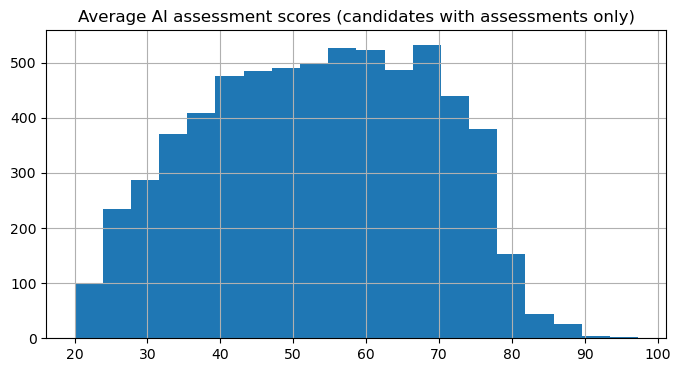

In [ ]:
print('Candidates with any AI assessment score:',
      (df['avg_ai_assess_score'] > 0).sum())
df[df['avg_ai_assess_score']>0]['avg_ai_assess_score'].hist(bins=20,figsize=(8,4))
plt.title('Average AI assessment scores (candidates with assessments only)')
plt.show()


Saved by 5+ recruiters: 66279


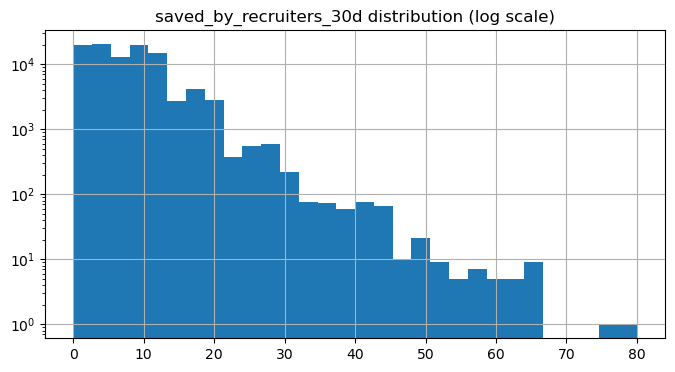

In [11]:
print('Saved by 5+ recruiters:',(df['saved_by_recruiters_30d']>=5).sum())
df['saved_by_recruiters_30d'].hist(bins=30,log=True,figsize=(8,4))
plt.title('saved_by_recruiters_30d distribution (log scale)')
plt.show()

In [13]:
sub=pd.read_csv("C:/Users/husai/OneDrive/Desktop/redrob_1/outputs/submission.csv")
top=sub.merge(df,on='candidate_id').sort_values('rank')

print('=== Sanity Checks ===')

WRONG=['Marketing Manager','HR manager','Accountant','Sales Executive','Grapic Designer'
       ,'Content Writer','Civil Engineer','Mechanical Engineer']
top10_wrong=top.head(10)[top.head(10)['current_title'].isin(WRONG)]
assert  len(top10_wrong)==0,f"FAIL: wrong titles in top 10:{top10_wrong["current_title"].tolist}"
print(" No  wrong-title  candidates in top 10")

top10_exp=top.head(10)['years_of_experience']
print(f'Top-10 experience range:{top10_exp.min():.1f}-{top10_exp.max():.1f} yrs')
print(f'Top-10  meadian  experiences:{top10_exp.median():.1f} yrs')

top10_days=top.head(10)['days_since_active']
assert top10_days.max() <=90,f"FAIL: gost in top 10 (max inactive {top10_days.max()}days)"
print(f' Top-10 all active within {top10_days.max()} days')

top10_gh=top.head(10)[top.head(10)['github_activity_score']>0]['github_activity_score']
print(f'Top-10 Github score (those with Github): avg {top10_gh.mean():.1f}')

scores=sub['score'].tolist()
violations=[(i,scores[i],scores[i+1]) for i in range(len(scores)-1) if scores[i]<scores[i+1]]
assert len(violations)==0,f'FAIL: score not non-increasing at rows {violations}'
print('Scores are non-increasing (submission rule  satisfied)')
print('\n ALL checks passed')


=== Sanity Checks ===
 No  wrong-title  candidates in top 10
Top-10 experience range:4.2-8.6 yrs
Top-10  meadian  experiences:6.4 yrs
 Top-10 all active within 76 days
Top-10 Github score (those with Github): avg 77.4
Scores are non-increasing (submission rule  satisfied)

 ALL checks passed
